In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import plotly.express as px
from sklearn.decomposition import PCA, IncrementalPCA

In [6]:
df = pd.read_csv("Country-data.csv")

In [7]:
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [8]:
df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


## Dataset Description

| Column Name   | Description                                                                 |
|---------------|-----------------------------------------------------------------------------|
| country       | Name of the country                                                         |
| child_mort    | Deaths of children under 5 years per 1,000 live births                      |
| exports       | Exports of goods and services per capita (% of GDP per capita)              |
| health        | Total health spending per capita (% of GDP per capita)                      |
| imports       | Imports of goods and services per capita (% of GDP per capita)              |
| Income        | Net income per person                                                       |
| Inflation     | Annual growth rate of total GDP                                             |
| life_expec    | Average life expectancy at birth (years)                                    |
| total_fer     | Average number of children born per woman                                   |
| gdpp          | GDP per capita                                                              |

In [10]:
df.describe().T.style.background_gradient(cmap="Blues", axis=1)

,count,mean,std,min,25%,50%,75%,max
child_mort,167.000000,38.270060,40.328931,2.600000,8.250000,19.300000,62.100000,208.000000
exports,167.000000,41.108976,27.412010,0.109000,23.800000,35.000000,51.350000,200.000000
health,167.000000,6.815689,2.746837,1.810000,4.920000,6.320000,8.600000,17.900000
imports,167.000000,46.890215,24.209589,0.065900,30.200000,43.300000,58.750000,174.000000
income,167.000000,17144.688623,19278.067698,609.000000,3355.000000,9960.000000,22800.000000,125000.000000
inflation,167.000000,7.781832,10.570704,-4.210000,1.810000,5.390000,10.750000,104.000000
life_expec,167.000000,70.555689,8.893172,32.100000,65.300000,73.100000,76.800000,82.800000
total_fer,167.000000,2.947964,1.513848,1.150000,1.795000,2.410000,3.880000,7.490000
gdpp,167.000000,12964.155689,18328.704809,231.000000,1330.000000,4660.000000,14050.000000,105000.000000


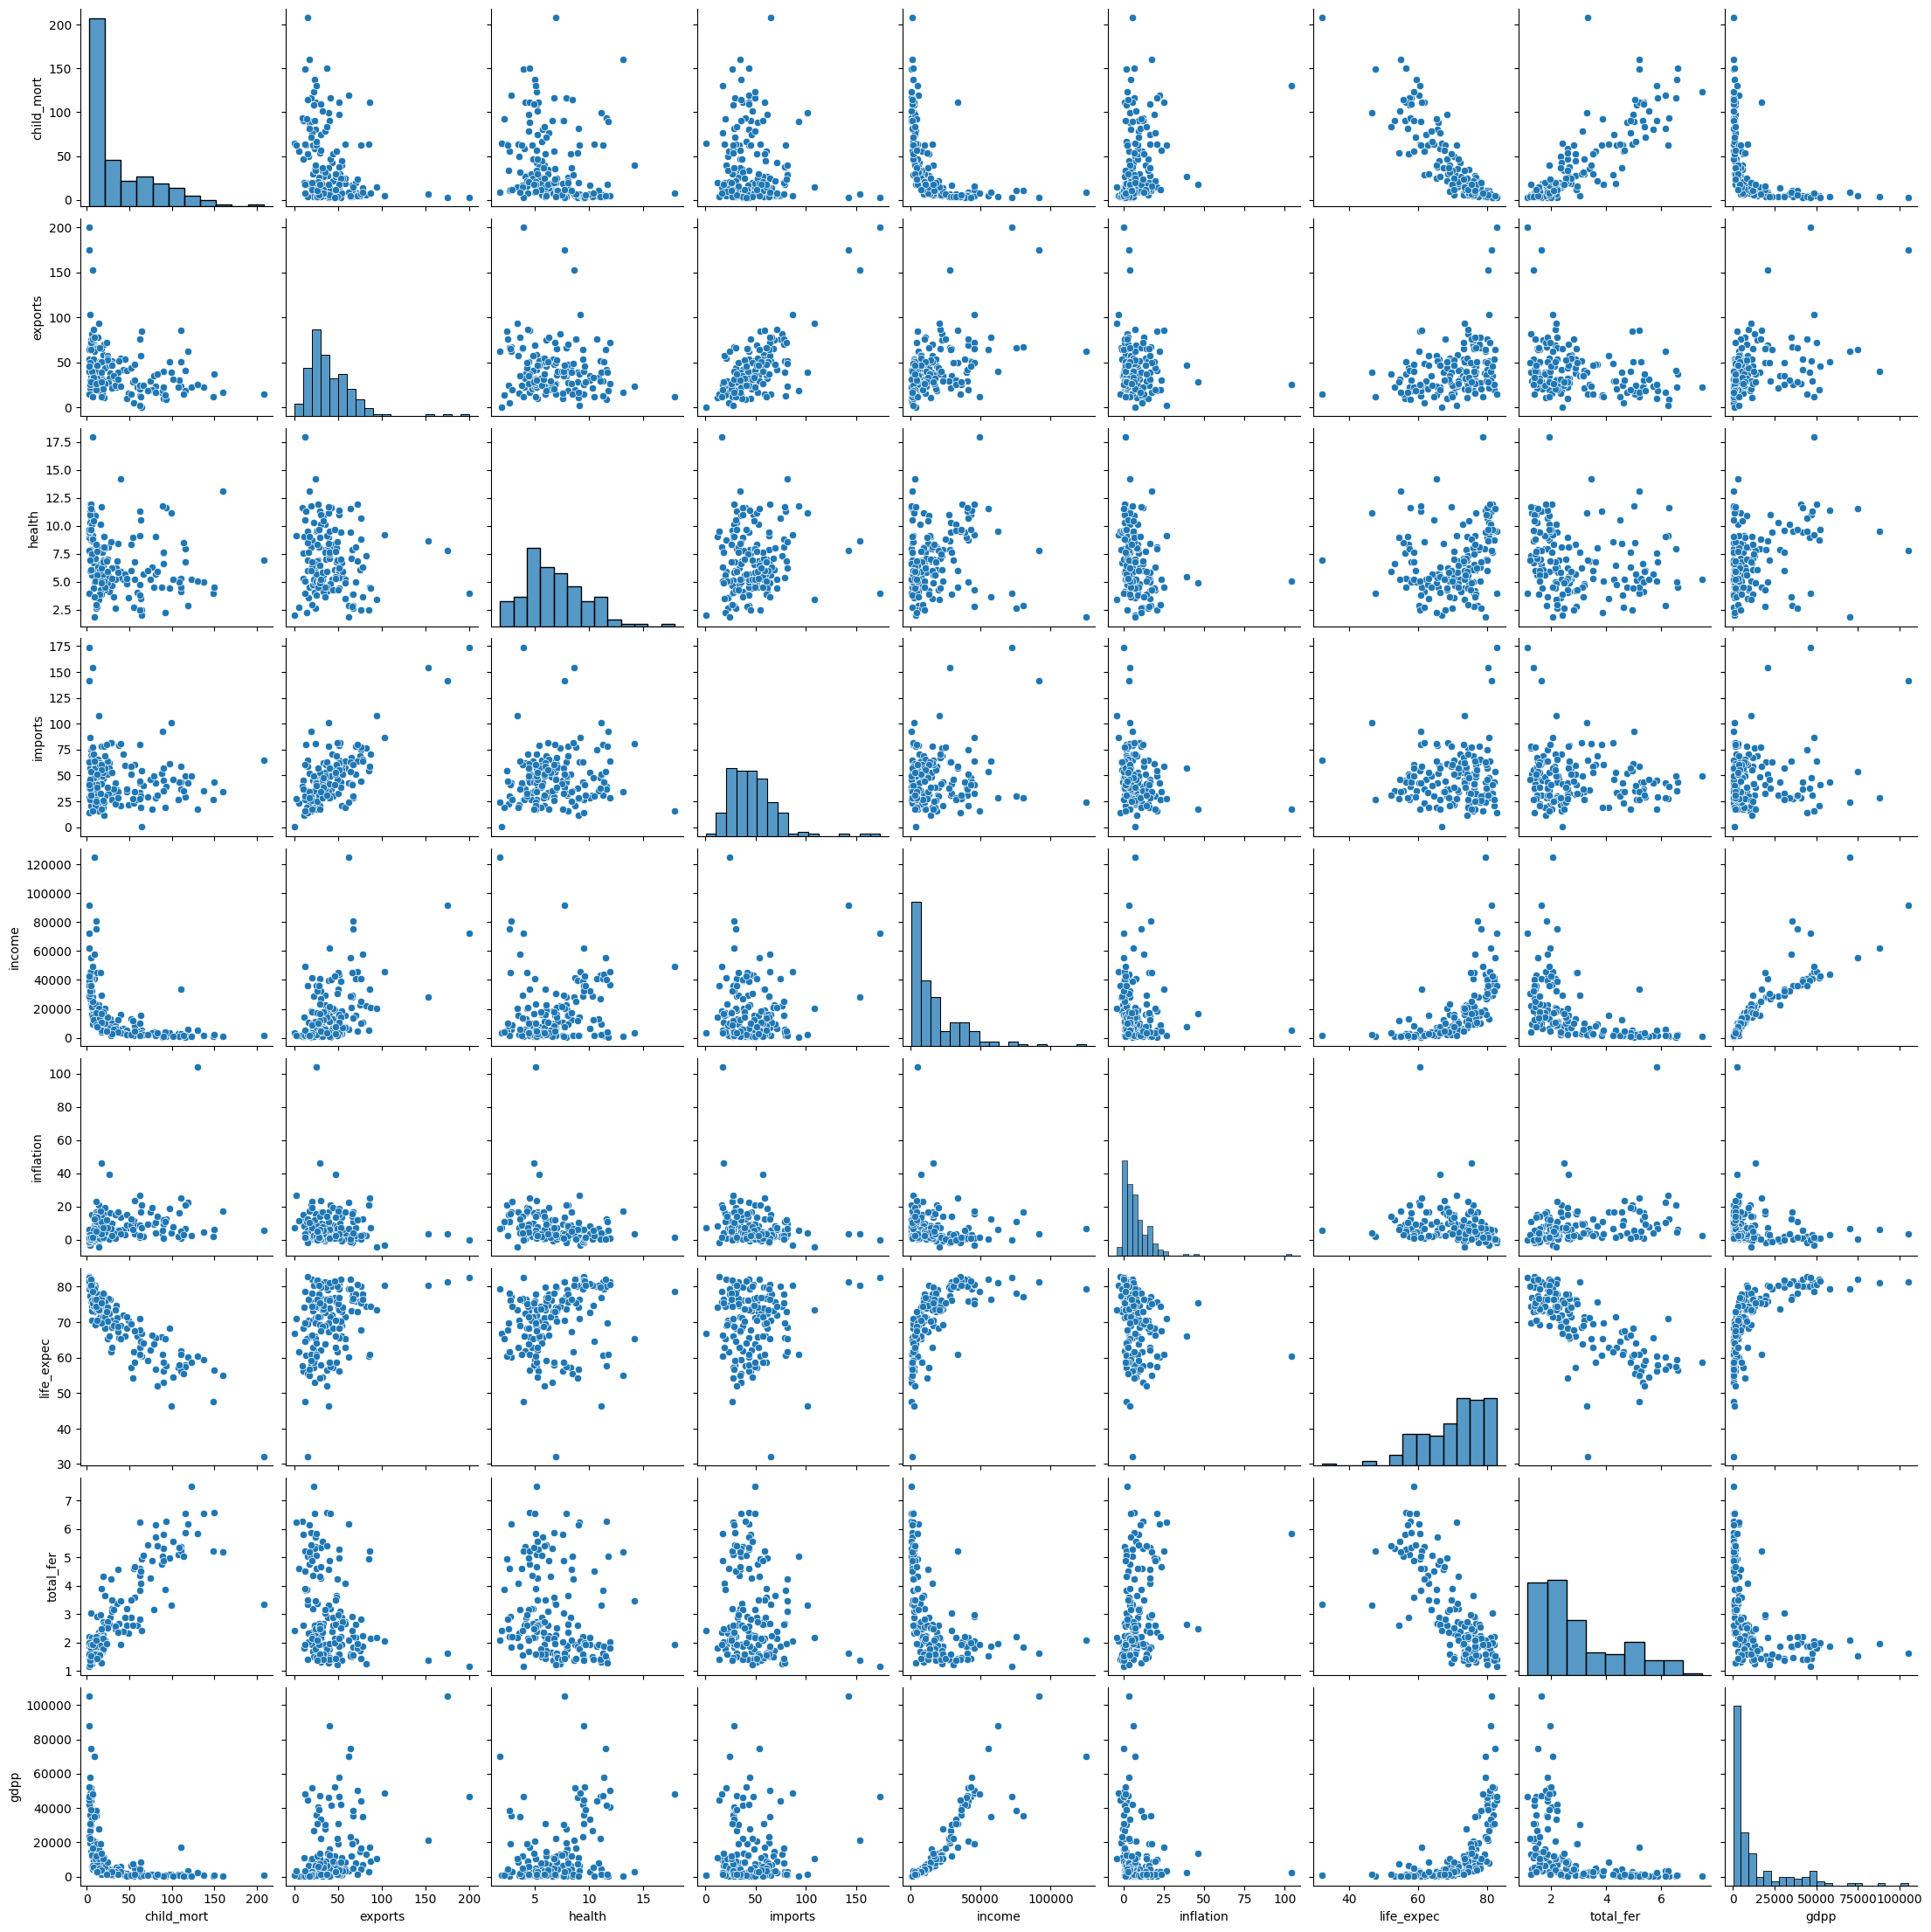

In [11]:
sns.pairplot(df)

In [13]:
df["country"].value_counts()

country
Afghanistan    1
Morocco        1
Myanmar        1
Namibia        1
Nepal          1
              ..
Georgia        1
Germany        1
Ghana          1
Greece         1
Zambia         1
Name: count, Length: 167, dtype: int64

In [14]:
report = ProfileReport(df, minimal=False, progress_bar=False)
report.to_file("Country_data_report.html")

100%|██████████| 10/10 [00:00<00:00, 31.33it/s]


In [15]:
outlier_summary = {}

for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

In [16]:
outlier_summary

{'child_mort': 4,
 'exports': 5,
 'health': 2,
 'imports': 4,
 'income': 8,
 'inflation': 5,
 'life_expec': 3,
 'total_fer': 1,
 'gdpp': 25}

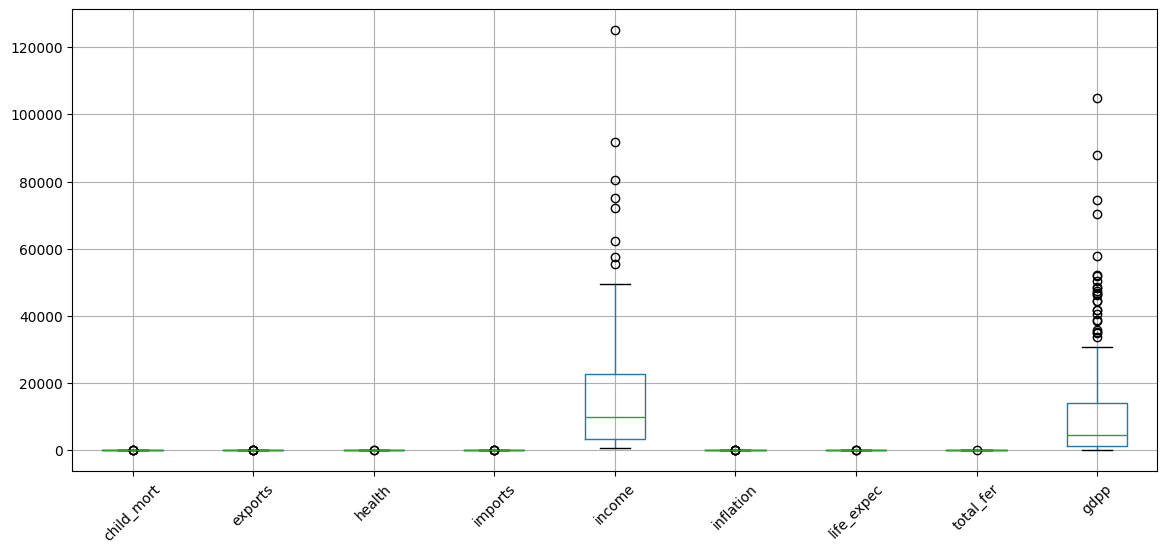

In [17]:
df.select_dtypes(include=np.number).boxplot(figsize=(14, 6))
plt.xticks(rotation=45)
plt.show()

In [18]:
# Example

gdpp = df[["gdpp"]]

# StandardScaler
ss = StandardScaler()
gdpp_standard = ss.fit_transform(gdpp)

# RobustScaler
rs = RobustScaler()
gdpp_robust = rs.fit_transform(gdpp)

comparison = (
    pd.DataFrame(
        {
            "Original": df["gdpp"],
            "StandardScaler": gdpp_standard.flatten(),
            "RobustScaler": gdpp_robust.flatten(),
            "Country": df["country"],
        }
    )
    .sort_values("Original", ascending=False)
    .head(10)
)

print(comparison)

     Original  StandardScaler  RobustScaler        Country
91     105000        5.036507      7.888365     Luxembourg
114     87800        4.095266      6.536164         Norway
145     74600        3.372918      5.498428    Switzerland
123     70300        3.137608      5.160377          Qatar
44      58000        2.464511      4.193396        Denmark
144     52100        2.141643      3.729560         Sweden
7       51900        2.130699      3.713836      Australia
110     50300        2.043141      3.588050    Netherlands
73      48700        1.955584      3.462264        Ireland
159     48400        1.939167      3.438679  United States



## Observations from Data

- `gdpp` shows the **highest number of outliers (25)**, indicating large variation across countries.
- `income` also contains a **notable number of outliers (8)**.
- `inflation`, `exports`, and `imports` show **moderate outlier presence**.
- `life_expec`, `health`, and `total_fer` have **very few outliers**, suggesting more stable distributions.

---

### Outlier Handling Decision
Outliers were **not removed** because:
- The objective is **clustering**, not prediction
- Removing outliers would eliminate important country groups
- Economic extremes help define meaningful clusters

---

### Scaling Choice

**StandardScaler was avoided** because it relies on the mean and standard deviation, which are highly sensitive to extreme values. This caused most data points to be compressed, negatively affecting distance-based clustering methods such as DBSCAN.

**RobustScaler was selected** because it uses the median and interquartile range (IQR), making it resistant to outliers and preserving meaningful distances between data points.


In [19]:
df.head(1)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553


In [20]:
data = df.drop(columns="country")
data.head(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090


In [21]:
colmns = data.columns
colmns

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

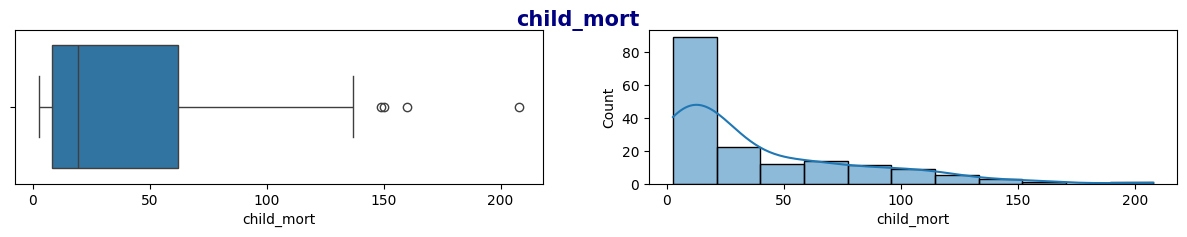

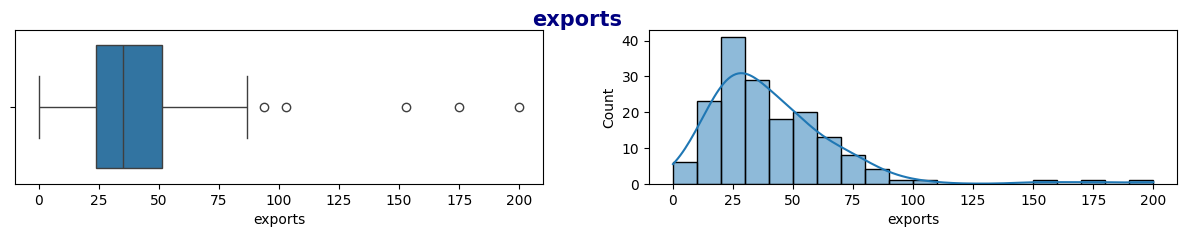

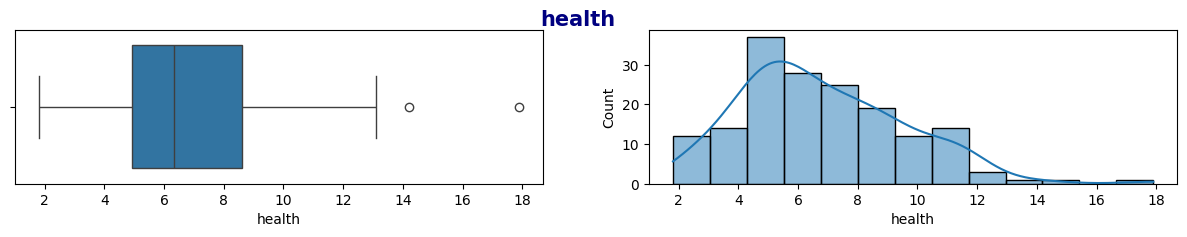

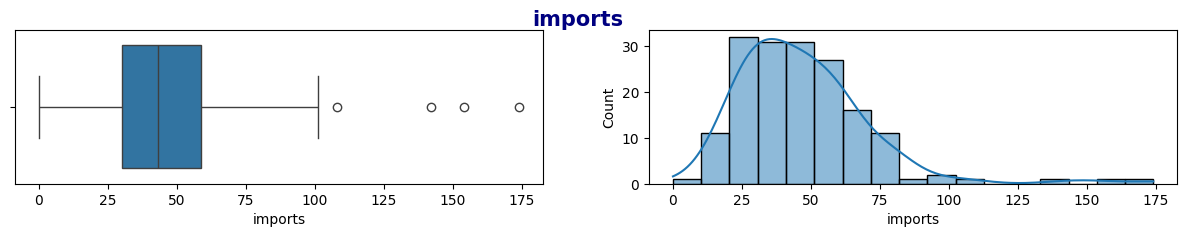

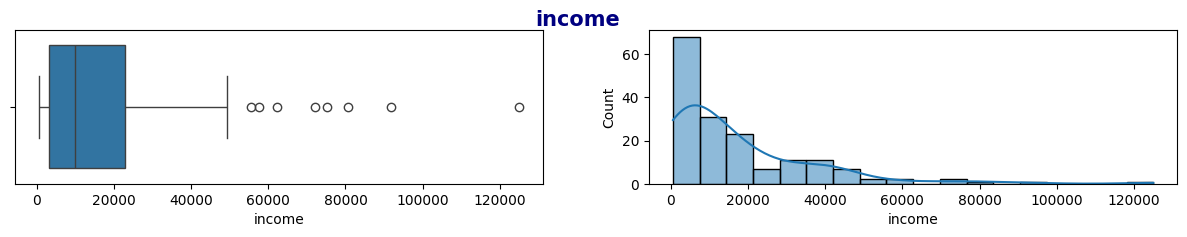

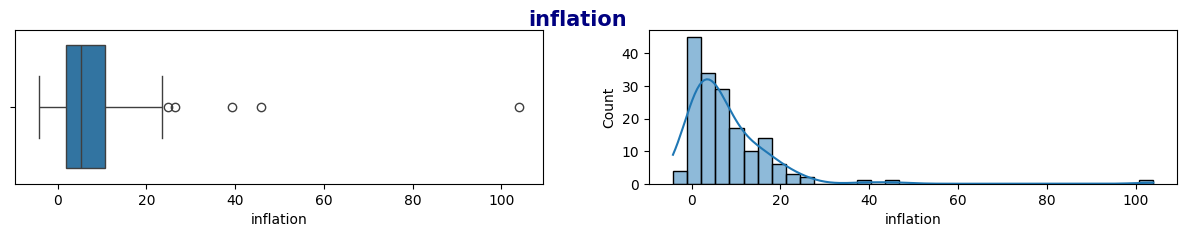

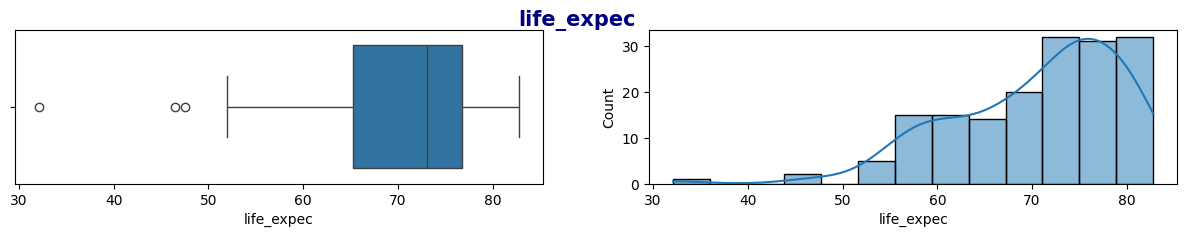

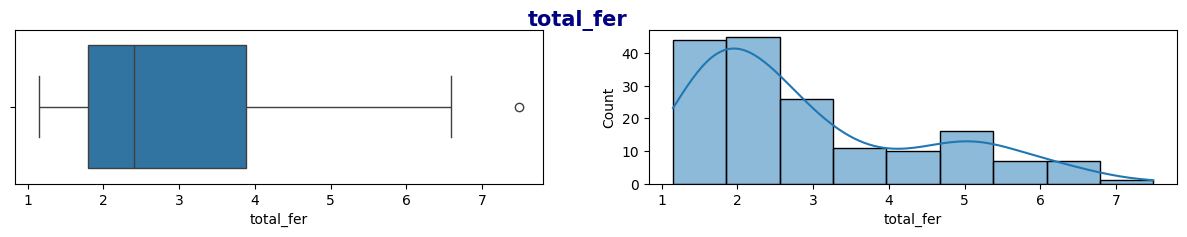

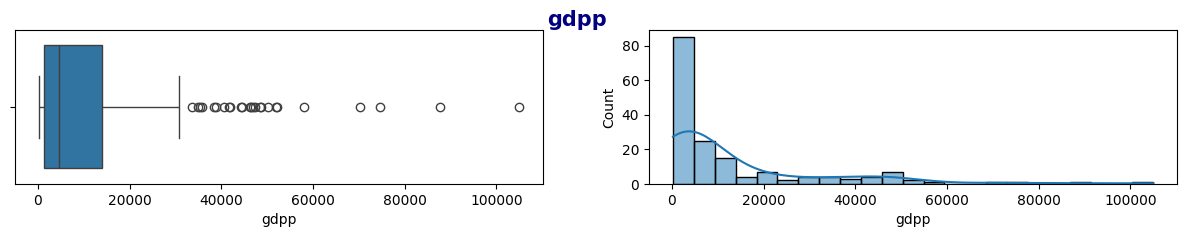

In [22]:
for i in range(len(colmns)):
    fig, ax = plt.subplots(1, 2, figsize=(15, 2))
    plt.suptitle(colmns[i], fontsize=15, fontweight="bold", color="navy")
    # Left
    sns.boxplot(x=colmns[i], data=data, ax=ax[0])
    # Right
    sns.histplot(data[colmns[i]], ax=ax[1], kde=True)

In [23]:
data_scaled = RobustScaler().fit_transform(data)
data_scaled

array([[ 1.31662024, -0.90744102,  0.3423913 , ..., -1.46956522,
         1.63549161, -0.32287736],
       [-0.05013928, -0.25408348,  0.0625    , ...,  0.27826087,
        -0.36450839, -0.04481132],
       [ 0.14856082,  0.12341198, -0.58423913, ...,  0.29565217,
         0.23021583, -0.01572327],
       ...,
       [ 0.07428041,  1.3430127 ,  0.14130435, ...,  0.        ,
        -0.2206235 , -0.26336478],
       [ 0.68709378, -0.1814882 , -0.30978261, ..., -0.48695652,
         1.08393285, -0.26336478],
       [ 1.18477252,  0.07259528, -0.11684783, ..., -1.83478261,
         1.43405276, -0.25157233]])

In [26]:
pca = PCA(n_components=9).fit(data_scaled)
exp = pca.explained_variance_ratio_
print(exp)

[0.48841948 0.16547786 0.14891017 0.0942477  0.0600765  0.01522075
 0.01207877 0.00994172 0.00562705]


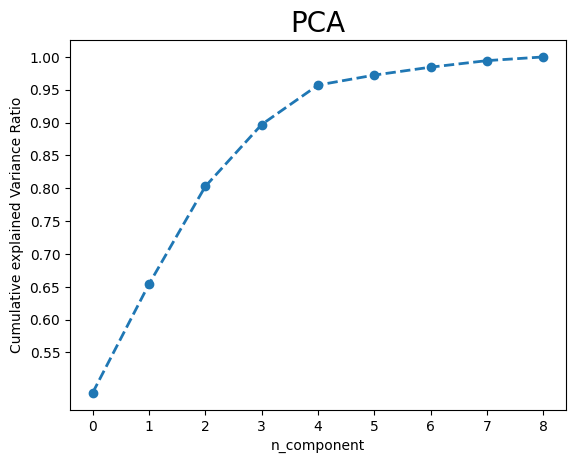

In [27]:
plt.plot(np.cumsum(exp), linewidth=2, marker="o", linestyle="--")
plt.title("PCA", fontsize=20)
plt.xlabel("n_component")
plt.ylabel("Cumulative explained Variance Ratio")
plt.yticks(np.arange(0.55, 1.05, 0.05))
plt.show()

In [37]:
final_pca = IncrementalPCA(n_components=5).fit_transform(data_scaled)

In [38]:
final_pca.shape

(167, 5)

In [32]:
data.shape

(167, 9)

In [ ]:
pc = np.transpose(final_pca)

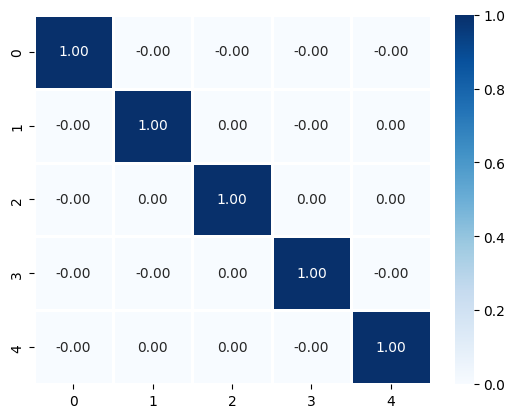

In [40]:
corrmat = np.corrcoef(pc)
sns.heatmap(data=corrmat, annot=True, fmt=".2f", linewidth=0.75, cmap="Blues")
plt.show()

In [43]:
pc

array([[-2.29449737e+00, -2.74237720e-01, -7.16443144e-01,
        -2.05968340e+00,  6.30200377e-01, -4.52976534e-01,
        -7.21476056e-01,  3.01021799e+00,  3.34708593e+00,
        -4.75819106e-01,  1.39406395e+00,  1.58164956e+00,
        -1.41251492e+00,  7.39228325e-01, -8.95088583e-02,
         3.45938263e+00, -1.64757619e-01, -1.96639135e+00,
        -5.97418064e-01, -1.01783271e+00,  9.84115247e-02,
        -7.65030091e-01, -2.61465427e-01,  2.85605037e+00,
         3.15210148e-01, -2.31703176e+00, -2.34335433e+00,
        -8.16191617e-01, -2.04574364e+00,  2.95699286e+00,
        -5.37037636e-01, -2.73887723e+00, -2.38346753e+00,
         4.31051100e-01, -5.34790805e-01, -4.08146227e-01,
        -1.76423427e+00, -2.43308043e+00, -1.37679330e+00,
         1.87405730e-01, -1.81814620e+00,  6.90706136e-01,
         2.14340097e+00,  1.71811665e+00,  3.78804972e+00,
        -5.76942483e-01, -5.09033400e-01, -1.11075233e+00,
        -4.93479485e-01, -2.54331981e-01, -2.21489085e+0

In [45]:
pc_df = pd.DataFrame(
    {
        "PC1": pc[0],
        "PC2": pc[1],
        "PC3": pc[2],
        "PC4": pc[3],
        "PC5": pc[4],
    }
)
pc_df

,PC1,PC2,PC3,PC4,PC5
0,-2.294497,-0.073436,-0.292536,1.299358,0.196232
1,-0.274238,-0.688078,-0.412288,-0.977408,0.091066
2,-0.716443,0.781495,0.040623,-1.051281,-0.370447
3,-2.059683,1.426688,1.640058,0.956700,-0.650817
4,0.630200,-0.782961,0.086896,-0.595073,-0.174718
...,...,...,...,...,...
162,-0.881589,-0.919023,0.440913,-0.025240,-0.331739
163,-0.998258,3.994159,0.135761,-1.579482,0.680869
164,-0.266296,-0.481296,1.617618,-0.968556,0.745306
165,-1.877975,1.393601,0.294705,-0.244115,0.117096


## Step 1: Choosing `min_samples`

A common rule of thumb for DBSCAN is:

**min_samples = 2 × number of features**

Since the dataset has **9 numerical features**:

**min_samples = 2 × 9 = 18**

In [27]:
k = 18

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(data_scaled)
distances, indices = neighbors_fit.kneighbors(data_scaled)
k_distances = np.sort(distances[:, -1])

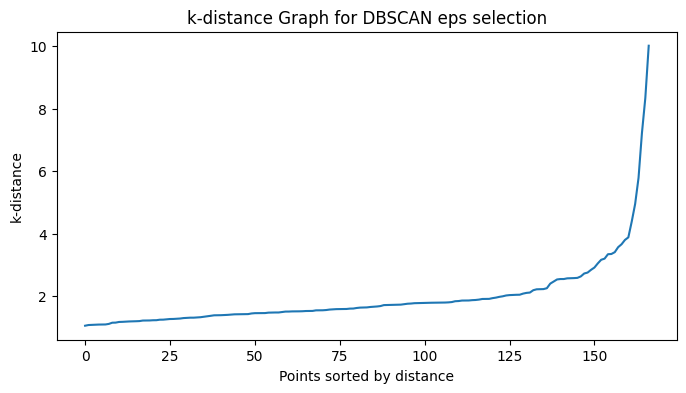

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("k-distance")
plt.title("k-distance Graph for DBSCAN eps selection")
plt.show()

In [29]:
results = []

for eps in [1.2, 1.3, 1.4, 1.5]:
    for min_s in [5, 8, 10, 12, 15]:

        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(data_scaled)

        # for noise
        mask = labels != -1
        n_clusters = len(set(labels[mask]))

        if n_clusters > 1:
            score = silhouette_score(data_scaled[mask], labels[mask])
        else:
            score = -1
        results.append((eps, min_s, n_clusters, score))


results

[(1.2, 5, 1, -1),
 (1.2, 8, 2, 0.4262086763308715),
 (1.2, 10, 3, 0.3779018728758795),
 (1.2, 12, 3, 0.3971731611502847),
 (1.2, 15, 1, -1),
 (1.3, 5, 1, -1),
 (1.3, 8, 1, -1),
 (1.3, 10, 1, -1),
 (1.3, 12, 2, 0.43467607790683643),
 (1.3, 15, 2, 0.3813033325812969),
 (1.4, 5, 1, -1),
 (1.4, 8, 1, -1),
 (1.4, 10, 1, -1),
 (1.4, 12, 2, 0.413915030307307),
 (1.4, 15, 2, 0.42160621650948743),
 (1.5, 5, 1, -1),
 (1.5, 8, 1, -1),
 (1.5, 10, 1, -1),
 (1.5, 12, 1, -1),
 (1.5, 15, 2, 0.40203414506117363)]

In [30]:
df_results = pd.DataFrame(
    results, columns=["eps", "min_samples", "n_clusters", "silhouette"]
)

df_results.sort_values("silhouette", ascending=False)

,eps,min_samples,n_clusters,silhouette
8,1.3,12,2,0.434676
1,1.2,8,2,0.426209
14,1.4,15,2,0.421606
13,1.4,12,2,0.413915
19,1.5,15,2,0.402034
3,1.2,12,3,0.397173
9,1.3,15,2,0.381303
2,1.2,10,3,0.377902
18,1.5,12,1,-1.000000
17,1.5,10,1,-1.000000


Reducing `eps` revealed weak density-based structure in the data.  
The best DBSCAN setting (`eps = 1.3`, `min_samples = 12`) produced **2 clusters** with a **silhouette score of 0.43**.

In [31]:
db = DBSCAN(eps=1.3, min_samples=12)
labels = db.fit_predict(data_scaled)
np.unique(labels, return_counts=True)

(array([-1,  0,  1], dtype=int64), array([ 48, 103,  16], dtype=int64))

In [32]:
db.labels_

array([ 0,  0,  0, -1,  0,  0,  0,  1,  1,  0,  0, -1,  0,  0, -1, -1,  0,
        0,  0,  0,  0, -1,  0, -1,  0,  0, -1,  0,  0,  1,  0,  0,  0,  0,
        0,  0,  0, -1, -1,  0,  0,  0, -1,  0,  1,  0,  0,  0,  0, -1,  0,
        0,  0,  1,  1, -1,  0,  0,  1,  0,  1,  0,  0,  0,  0,  0, -1,  0,
        1,  0,  0,  0, -1, -1,  1,  1,  0,  1,  0,  0,  0, -1, -1,  0,  0,
        0,  0, -1, -1, -1,  0, -1,  0,  0,  0,  0,  0,  0, -1, -1,  0, -1,
        0, -1,  0,  0,  0,  0,  0,  0, -1,  1,  0, -1, -1, -1,  0,  0,  0,
        0,  0,  0,  0, -1,  0,  0, -1,  0, -1,  0,  0, -1, -1, -1,  0, -1,
       -1, -1,  0,  1,  0,  0, -1,  0,  1, -1, -1,  0,  0, -1,  0,  0,  0,
        0, -1,  0,  0, -1,  1, -1,  0,  0,  0, -1, -1, -1,  0],
      dtype=int64)

In [33]:
df["cluster"] = labels

for cluster_id in [0, 1, -1]:
    cluster_data = df[df["cluster"] == cluster_id]
    print(f"Number of countries: {len(cluster_data)}")
    print(f"\nMean values:")
    print(cluster_data[["child_mort", "gdpp", "life_expec", "income"]].mean())
    print(f"\nCountries:")
    print(cluster_data["country"].tolist())

Number of countries: 103

Mean values:
child_mort      39.805825
gdpp          5403.398058
life_expec      69.604854
income        9715.339806
dtype: float64

Countries:
['Afghanistan', 'Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Cambodia', 'Cameroon', 'Cape Verde', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Czech Republic', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Eritrea', 'Estonia', 'Fiji', 'Gambia', 'Georgia', 'Ghana', 'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Hungary', 'India', 'Indonesia', 'Iran', 'Jamaica', 'Jordan', 'Kazakhstan', 'Kenya', 'Kyrgyz Republic', 'Lao', 'Latvia', 'Lebanon', 'Lithuania', 'Macedonia, FYR', 'Madagascar', 'Malawi', 'Malaysia', 'Maldives', 'Mali', 'Mauritius', 'Mold

In [34]:
# Find top 10 countries in Cluster 0
cluster_0 = df[df["cluster"] == 0]
print(" TOP 10 MOST CRITICAL IN CLUSTER 0 ")
print(
    cluster_0.nlargest(10, "child_mort")[
        ["country", "child_mort", "gdpp", "life_expec"]
    ]
)

# Find the top 10 critical outliers
outliers = df[df["cluster"] == -1]
print("\n TOP 10 MOST CRITICAL OUTLIERS ")
print(
    outliers.nlargest(10, "child_mort")[["country", "child_mort", "gdpp", "life_expec"]]
)

 TOP 10 MOST CRITICAL IN CLUSTER 0 
                      country  child_mort  gdpp  life_expec
32                       Chad       150.0   897        56.5
31   Central African Republic       149.0   446        47.5
97                       Mali       137.0   708        59.5
112                     Niger       123.0   348        58.8
25               Burkina Faso       116.0   575        57.9
64              Guinea-Bissau       114.0   547        55.6
17                      Benin       111.0   758        61.8
40              Cote d'Ivoire       111.0  1220        56.3
63                     Guinea       109.0   648        58.0
28                   Cameroon       108.0  1310        57.3

 TOP 10 MOST CRITICAL OUTLIERS 
               country  child_mort   gdpp  life_expec
66               Haiti       208.0    662        32.1
132       Sierra Leone       160.0    399        55.0
113            Nigeria       130.0   2330        60.5
3               Angola       119.0   3530        60.1
3

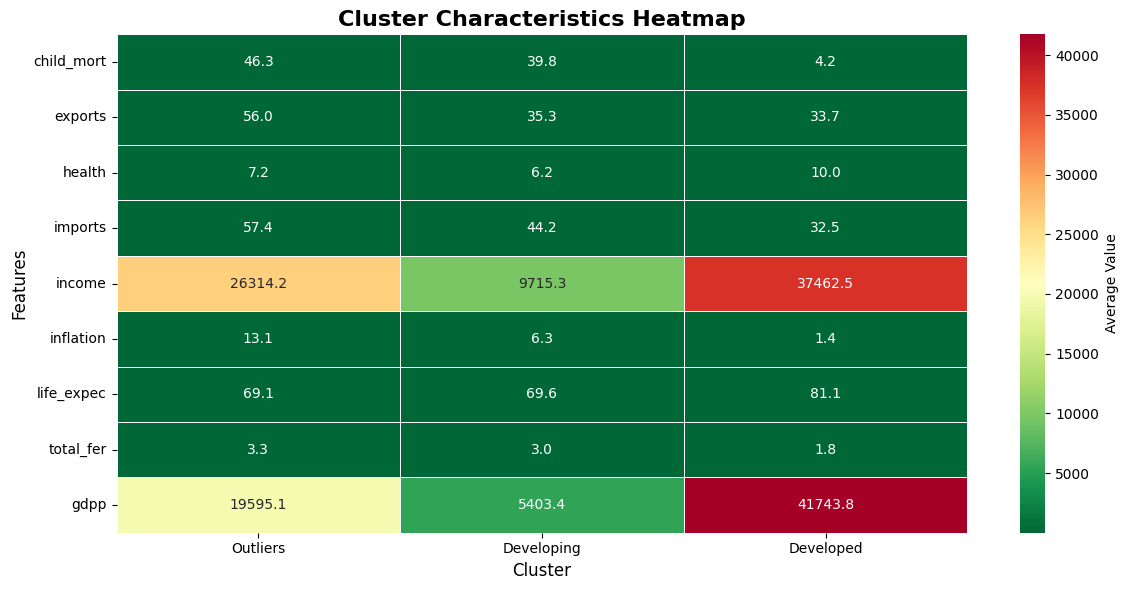

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
Outliers,46.341667,55.98375,7.166042,57.41250,26314.229167,13.110875,69.079167,3.259167,19595.083333
Developing,39.805825,35.32601,6.156408,44.22297,9715.339806,6.283291,69.604854,2.977767,5403.398058
Developed,4.168750,33.71250,10.008750,32.49375,37462.500000,1.441563,81.106250,1.822500,41743.750000


In [35]:
# mapping
labels_map = {-1: "Outliers", 0: "Developing", 1: "Developed"}
cluster_summary = df.groupby("cluster")[
    [
        "child_mort",
        "exports",
        "health",
        "imports",
        "income",
        "inflation",
        "life_expec",
        "total_fer",
        "gdpp",
    ]
].mean()
cluster_summary.index = cluster_summary.index.map(labels_map)

plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_summary.T,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "Average Value"},
)
plt.title("Cluster Characteristics Heatmap", fontsize=16, fontweight="bold")
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()
cluster_summary

In [36]:
df["cluster"].value_counts()

cluster
 0    103
-1     48
 1     16
Name: count, dtype: int64

In [37]:
df_map = df.copy()


def categorize(row):
    if row["cluster"] == 1:
        return "Developed (No Aid)"
    elif row["cluster"] == 0:
        return "High Priority (Aid Needed)"
    elif row["cluster"] == -1:  # Outliers
        if row["gdpp"] > 30000:
            return "Wealthy Outlier (No Aid)"
        elif row["child_mort"] > 100:
            return "Crisis Outlier (Emergency Aid)"
        else:
            return "Wealth Paradox (Targeted Aid)"


df_map["Category"] = df_map.apply(categorize, axis=1)

In [38]:
fig = px.choropleth(
    df_map,
    locationmode="country names",
    locations="country",
    color="Category",
    title="HELP International: Detailed Priority Classification (Outliers Categorized)",
    color_discrete_map={
        "High Priority (Aid Needed)": "#DB1C18",
        "Crisis Outlier (Emergency Aid)": "#8B0000",
        "Wealth Paradox (Targeted Aid)": "#FFA500",
        "Wealthy Outlier (No Aid)": "#FFD700",
        "Developed (No Aid)": "#67E232",
    },
    hover_data=["child_mort", "gdpp", "life_expec", "cluster"],
)
fig.update_layout(height=600)
fig.show()

C:\Users\Vatsal.mehta\AppData\Local\Temp\ipykernel_9908\743928531.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth( df_map, locationmode='country names', locations='country', color='Category', title='HELP International: Detailed Priority Classification (Outliers Categorized)',


In [39]:
check_countries = ["China", "Russia", "India", "United States"]
print(
    df[df["country"].isin(check_countries)][
        ["country", "cluster", "child_mort", "gdpp", "life_expec", "income"]
    ]
)

           country  cluster  child_mort   gdpp  life_expec  income
34           China        0        15.7   4560        74.6    9530
69           India        0        58.8   1350        66.2    4410
125         Russia        0        10.0  10700        69.2   23100
159  United States       -1         7.3  48400        78.7   49400


In [40]:
df_new = df.copy()


def categorize_new(row):
    # Well Developed DBSCAN Cluster 1
    if row["cluster"] == 1 or row["gdpp"] > 30000:
        return "Well Developed"

    elif row["gdpp"] > 10000:
        return "Developed"

    elif row["gdpp"] >= 2500:
        return "Developing"

    else:
        return "Undeveloped"


df_new["Category"] = df_new.apply(categorize_new, axis=1)

In [41]:
fig_new = px.choropleth(
    df_new,
    locationmode="country names",
    locations="country",
    color="Category",
    title="NEW: 4-Tier Classification (GDP-Based)",
    color_discrete_map={
        "Undeveloped": "#DB1C18",
        "Developing": "#EBB331",
        "Developed": "#51A2DB",
        "Well Developed": "#67E232",
    },
    category_orders={
        "Category": ["Undeveloped", "Developing", "Developed", "Well Developed"]
    },
    hover_data=["child_mort", "gdpp", "life_expec", "cluster"],
)
fig_new.update_layout(height=500, title_x=0.5)

C:\Users\Vatsal.mehta\AppData\Local\Temp\ipykernel_9908\2049505944.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [42]:
india_data = df_new[df_new["country"] == "India"][
    ["country", "gdpp", "child_mort", "cluster", "Category"]
]
print(india_data)

   country  gdpp  child_mort  cluster     Category
69   India  1350        58.8        0  Undeveloped


In [43]:
print("KEY INSIGHTS")
print("=" * 100)

# Top 10 most critical
print("\nTOP 10 MOST CRITICAL COUNTRIES (Immediate Aid Required)")
top10 = df_map.nlargest(10, "child_mort")[
    ["country", "Category", "child_mort", "gdpp", "life_expec"]
]
print(top10.to_string(index=False))

KEY INSIGHTS

TOP 10 MOST CRITICAL COUNTRIES (Immediate Aid Required)
                 country                       Category  child_mort  gdpp  life_expec
                   Haiti Crisis Outlier (Emergency Aid)       208.0   662        32.1
            Sierra Leone Crisis Outlier (Emergency Aid)       160.0   399        55.0
                    Chad     High Priority (Aid Needed)       150.0   897        56.5
Central African Republic     High Priority (Aid Needed)       149.0   446        47.5
                    Mali     High Priority (Aid Needed)       137.0   708        59.5
                 Nigeria Crisis Outlier (Emergency Aid)       130.0  2330        60.5
                   Niger     High Priority (Aid Needed)       123.0   348        58.8
                  Angola Crisis Outlier (Emergency Aid)       119.0  3530        60.1
            Burkina Faso     High Priority (Aid Needed)       116.0   575        57.9
        Congo, Dem. Rep. Crisis Outlier (Emergency Aid)       116.0   

In [44]:
data_scaled

array([[ 1.31662024, -0.90744102,  0.3423913 , ..., -1.46956522,
         1.63549161, -0.32287736],
       [-0.05013928, -0.25408348,  0.0625    , ...,  0.27826087,
        -0.36450839, -0.04481132],
       [ 0.14856082,  0.12341198, -0.58423913, ...,  0.29565217,
         0.23021583, -0.01572327],
       ...,
       [ 0.07428041,  1.3430127 ,  0.14130435, ...,  0.        ,
        -0.2206235 , -0.26336478],
       [ 0.68709378, -0.1814882 , -0.30978261, ..., -0.48695652,
         1.08393285, -0.26336478],
       [ 1.18477252,  0.07259528, -0.11684783, ..., -1.83478261,
         1.43405276, -0.25157233]])

---

# PROJECT SUMMARY: HELP International Country Clustering Analysis

## Business Objective

HELP International, a humanitarian NGO, raised **$10 million** and needs a data-driven strategy to identify countries in dire need of aid. The CEO requested a clustering analysis to categorize countries based on socio-economic and health indicators.

---

## Dataset Overview

**Source**: Country-data.csv  
**Records**: 167 countries  
**Features**: 10 variables

| Feature | Description |
|---------|-------------|
| `country` | Country name |
| `child_mort` | Deaths of children under 5 years per 1,000 live births |
| `exports` | Exports of goods and services (% of GDP) |
| `health` | Total health spending (% of GDP) |
| `imports` | Imports of goods and services (% of GDP) |
| `income` | Net income per person ($) |
| `inflation` | Annual GDP growth rate (%) |
| `life_expec` | Average life expectancy at birth (years) |
| `total_fer` | Average number of children per woman |
| `gdpp` | GDP per capita ($) |

**Data Quality**: No missing values, no duplicate entries

---

## Exploratory Data Analysis (EDA)

### Key Findings:

1. **Wide GDP Range**: $231 (Burundi) to $105,000 (Luxembourg)
2. **Child Mortality Extremes**: 2.6 (Iceland) to 208 (Haiti)
3. **Life Expectancy Gap**: 32.1 years (Haiti) to 82.8 years (Japan)
4. **Outliers Present**: 
   - Extreme wealth: Luxembourg, Norway, Singapore
   - Extreme poverty: Haiti, Chad, Niger
   - Wealth paradox: Equatorial Guinea (high GDP, high mortality)

### Outlier Analysis Decision:

**Issue**: Multiple outliers detected across features (25 outliers in `gdpp` alone)

**Decision**: **Did NOT remove outliers**  
**Rationale**: 
- Outliers represent real countries with genuine conditions (e.g., Haiti's crisis, Luxembourg's wealth)
- DBSCAN naturally handles outliers by marking them as noise (Cluster -1)
- Removing them would lose critical information for aid allocation

---

## Data Preprocessing

### Feature Scaling Strategy

**Challenge**: Features have vastly different scales (GDP: $231-$105,000 vs Inflation: -4.21% to 104%)

**Solution**: **RobustScaler** (chosen over StandardScaler)

**Why RobustScaler?**
- Uses median and IQR instead of mean and standard deviation
- Less sensitive to outliers
- Preserves relative distances between countries

**Validation**:
```python
# Comparison showed RobustScaler better handles extreme values
Luxembourg scaled: 7.89 (RobustScaler) vs 5.04 (StandardScaler)

```
---

### Why DBSCAN?

| Advantage          | Why Important for This Project                              |
| ------------------ | ----------------------------------------------------------- |
| No pre-specified K | We don't know how many development "tiers" exist            |
| Handles outliers   | Identifies special cases (oil-rich paradoxes, crisis zones) |
| Arbitrary shapes   | Countries don't cluster in spherical patterns               |
| Density-based      | Groups countries with similar socio-economic profiles       |

### Alternative Considered: K-Means

**Why Rejected:**
- Requires pre-defining the number of clusters
- Assumes spherical cluster shapes
- Assigns every country to a cluster (no outlier detection)

## Hyperparameter Tuning

### eps Selection
- Used **K-distance graph (elbow method)**
- Optimal value observed at **eps = 1.3**

### min_samples Selection
- Performed grid search using **silhouette score**
- Tested:
  - `eps`: [1.2, 1.3, 1.4, 1.5]
  - `min_samples`: [5, 8, 10, 12, 15]

### Best Result

| eps | min_samples | Clusters | Silhouette |
|-----|-------------|----------|------------|
| 1.3 | 12          | 2        | **0.435**  |
| 1.2 | 10          | 2        | 0.412      |
| 1.4 | 12          | 2        | 0.398      |

## Critical Issue: Cluster 0 Heterogeneity

### Problem
Cluster 0 grouped countries with vastly different GDP levels  
(from **$348 – Niger** to **$12,600 – Poland**).

Treating all of them as **“High Priority”** would imply equal aid allocation to countries with very different economic needs.

### Example
- **China:** GDP $4,560 → High Priority  
- **India:** GDP $1,350 → High Priority  
- **Russia:** GDP $10,700 → High Priority  

This classification is **not practical** for allocating a **$10M aid budget**.

## Solution: GDP-Based Sub-Classification

A **4-tier sub-classification** was applied to Cluster 0 by splitting countries using **GDP-based thresholds**. from official thresholds and data mentioned in reference.

## References

- World Bank – Country Income Classifications (2024)  
  https://datahelpdesk.worldbank.org/knowledgebase/articles/906519

- UN Human Development Report (2023)  
  https://hdr.undp.org/data-center/human-development-index

- WHO Global Health Observatory – Child Mortality  
  https://www.who.int/data/gho/data/themes/topics/topic-details/GHO/child-mortality-and-causes-of-death

- IMF World Economic Outlook Database  
  https://www.imf.org/en/Publications/WEO

- Scikit-learn DBSCAN Documentation  
  https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html